In [ ]:
# !pip install gymnasium
# !pip install gymnasium[classic-control]

import time
import matplotlib
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from collections import deque
from collections import defaultdict
from matplotlib import pyplot as plt
from IPython import display
from gymnasium.envs.classic_control import pendulum

Down here is the untrained environment. Just the pendulum

In [28]:
# env = gym.make("Pendulum-v1", render_mode="human", g=9.81)
# env = gym.wrappers.RescaleAction(env, min_action=-1.0, max_action=1.0)
# env = gym.wrappers.NormalizeObservation(env)
# env = gym.wrappers.NormalizeReward(env)
# obs, info = env.reset()

# for _ in range(1500):
#         # Take a random action to step the environment
#         action = env.action_space.sample() #random inputs
#         obs, reward, terminated, truncated, info = env.step(action)
        
#         # The window updates here
#         env.render()
        
#         if terminated or truncated:
#             env.close()

Took the Discretize_obs out of the assignment

In [ ]:
class Discretize_obs(gym.ObservationWrapper):
    def __init__(self, env, nvec=10):
        super().__init__(env)
        if isinstance(nvec, int):
            self.nvec_array = np.array([nvec] * np.prod(env.observation_space.shape, dtype=int))
        else:
            self.nvec_array = np.array(nvec)
            
        self.observation_space = gym.spaces.MultiDiscrete(self.nvec_array)
        self.olow = env.observation_space.low
        self.ohigh = env.observation_space.high

    def observation(self, obs):
        # Scale observation between 0 and 1, then multiply by the grid size
        scaled = (obs - self.olow) / (self.ohigh - self.olow) * self.nvec_array
        # Clip to ensure values stay strictly within the discrete bins [0, nvec-1]
        discretized = np.clip(scaled, 0, self.nvec_array - 1).astype(int)
        return tuple(discretized)


class DiscretizeAction(gym.ActionWrapper):
    def __init__(self, env, bins=5):
        super().__init__(env)
        self.bins = bins
        self.action_space = gym.spaces.Discrete(self.bins) # 5 discrete actions
        
        # Create an array mapping discrete actions to continuous torques
        # Pendulum torque bounds are usually [-2.0, 2.0]
        self.action_mapping = np.linspace(
            env.action_space.low[0], 
            env.action_space.high[0], 
            self.bins
        )

    def action(self, act):
        # Convert the discrete integer (e.g., 0, 1, 2) back into an array with the continuous float
        return np.array([self.action_mapping[act]], dtype=np.float32)

In [ ]:
def argmax(a):
    a = np.array(a)
    return np.random.choice(np.arange(len(a), dtype=int)[a == np.max(a)])

def Qlearn(env, nsteps=5000, alpha=0.2, eps=0.2, gamma=0.99):
    Qmat = defaultdict(float) 
    
    # Track the unwrapped environment to get elapsed steps
    env_time = env
    while hasattr(env_time, 'env') and not isinstance(env_time, gym.wrappers.TimeLimit):
        env_time = env_time.env
        
    ep_lengths = []
    ep_lengths_steps = []
    
    obs, info = env.reset()
    print('Training started...')
    
    for z in range(nsteps):
        # Epsilon-greedy action selection
        if np.random.uniform() < eps:
            action = env.action_space.sample()
        else:
            action = argmax([Qmat[obs, i] for i in range(env.action_space.n)])

        obs_new, reward, terminated, truncated, info = env.step(action)

        if terminated: 
            ep_lengths.append(env_time._elapsed_steps)
            ep_lengths_steps.append(z)
            
            # Terminal state update
            A = reward - Qmat[obs, action] 
            Qmat[obs, action] += alpha * A
            obs, info = env.reset()
            
        else: 
            # Normal TD update
            max_q_next = max(Qmat[obs_new, a] for a in range(env.action_space.n))
            A = reward + gamma * max_q_next - Qmat[obs, action]
            Qmat[obs, action] += alpha * A
            obs = obs_new
            
            if truncated: 
                ep_lengths.append(env_time._elapsed_steps)
                ep_lengths_steps.append(z)
                obs, info = env.reset()
                
    print('Training complete.')
    return Qmat, np.array(ep_lengths_steps), np.array(ep_lengths)

Training started...
Training complete.


In [37]:
env = gym.make("Pendulum-v1", render_mode="rgb_array", g=9.81)

env = Discretize_obs(env, nvec=20)   # 20 bins per observation dimension
env = DiscretizeAction(env, bins=5)  # 5 discrete torque choices

#Training loop
Qmat, steps, lengths = Qlearn(env, nsteps=1000000)

obs, info = env.reset()
try:
    env.render()
    truncated = terminated = False
    
    while not truncated and not terminated:
        # Choose the best action based on our trained Qmat
        action = argmax([Qmat[obs, i] for i in range(env.action_space.n)])
        obs, reward, terminated, truncated, info = env.step(action)
        
        env.render()
        time.sleep(1/60)
        
finally:
    env.close()

Training started...
Training complete.


Episode finished after 10000 steps.


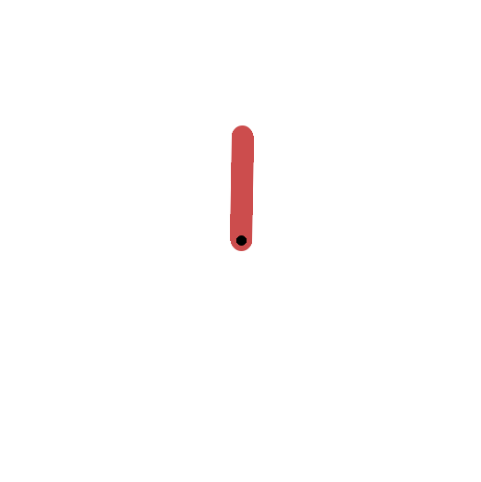

In [40]:
test_env = gym.make("Pendulum-v1", render_mode="rgb_array", g=9.81, max_episode_steps=10000)
test_env = Discretize_obs(test_env, nvec=20)
test_env = DiscretizeAction(test_env, bins=5)
obs, info = test_env.reset()
n_steps = 10000

# render in pyplot
fig, ax = plt.subplots(figsize=(6, 6))
img = ax.imshow(test_env.render())
ax.axis('off')
status_text = "Stabilizing..."

try:
    for step in range(n_steps):
        
        # large disturbance every 200 steps/10 seconds for big motor recovery
        if step > 0 and step % 200 == 0:
            theta, angular_velocity = test_env.unwrapped.state
            big_disturb = np.random.uniform(-4, 4) 
            test_env.unwrapped.state = np.array([theta, angular_velocity + big_disturb])
            status_text = f"Big push {big_disturb} at {step * 0.05:.1f}s!"
            
        # gentle disturbance every 60 steps/3 seconds to test fine motor recovery
        elif step > 0 and step % 60 == 0:
            theta, angular_velocity = test_env.unwrapped.state
            push = np.random.uniform(-1, 1)
            test_env.unwrapped.state = np.array([theta, angular_velocity + push])
            status_text = f"Nudging {push} at {step * 0.05:.1f}s"

        # reset status text periodically if no disturbance is actively happening
        elif step % 20 == 0: 
            status_text = "Balancing..."

        # pick best action from trained Q-table
        action = argmax([Qmat[obs, i] for i in range(test_env.action_space.n)])
        obs, reward, terminated, truncated, info = test_env.step(action)
        
        frame = test_env.render()
        img.set_data(frame)
        
        # adisplay the frame and the status text
        display.display(fig)
        print(f"Step: {step} / {n_steps} | Time: {step * 0.05:.2f}s | {status_text}")
        display.clear_output(wait=True)
        
        if terminated or truncated:
            print(f"Episode finished after {step + 1} steps.")
            break
finally:
    test_env.close()